In [1]:
import stdpopsim
import os
import tskit
import msprime
import numpy as np
import subprocess
import matplotlib.pyplot as plt
from IPython.display import display, SVG
import json
import bisect

In [42]:
import dendropy
from Espalier import MAF
def spr_dist_tree(tree1:tskit.Tree,tree2:tskit.Tree):
    #only for tree with 1 root
    if (tree1.num_roots>1 or tree2.num_roots>1):
        return None
    tree1_newick = tree1.as_newick()
    tree2_newick = tree2.as_newick()

    # Parse into dendropy trees
    taxon_namespace = dendropy.TaxonNamespace()
    t1 = dendropy.Tree.get(data=tree1_newick, schema="newick", taxon_namespace=taxon_namespace)
    t2 = dendropy.Tree.get(data=tree2_newick, schema="newick", taxon_namespace=taxon_namespace)


    t1.is_rooted = True
    t2.is_rooted = True

    t1.resolve_polytomies()
    t2.resolve_polytomies()

    if set([leaf.taxon.label for leaf in t1.leaf_node_iter()]) != set([leaf.taxon.label for leaf in t2.leaf_node_iter()]):
        print(f"Tree have mismatched taxa")


    # ass dendropy trees to Espalier
    spr_distance = MAF.get_spr_dist(t1, t2)
    return spr_distance
    
def spr_dist_ts(ts1:tskit.TreeSequence,ts2:tskit.TreeSequence,x1,x2,lam=None,scale=None,split_polytomy=None):#x1 and x2 are positions
    assert(len(x1)==len(x2))
    all_dist=[]
    tree1=ts1.at(0,sample_lists=True)
    tree2=ts2.at(0,sample_lists=True)
    for i in range(len(x1)):
        tree1.seek(x1[i])
        tree2.seek(x2[i])
        all_dist.append(spr_dist_tree(tree1,tree2))
    return np.array(all_dist)

def kc_dist_ts(ts1:tskit.TreeSequence,ts2:tskit.TreeSequence,x1,x2,lam=0,scale=True,split_polytomy=True):#x1 and x2 are positions
    assert(len(x1)==len(x2))
    all_dist=[]
    tree1=ts1.at(0,sample_lists=True)
    tree2=ts2.at(0,sample_lists=True)
    for i in range(len(x1)):
        tree1.seek(x1[i])
        tree2.seek(x2[i])
        if (tree1.num_roots>1 or tree2.num_roots>1):
            all_dist.append(None)
        else:
            if split_polytomy:
                if tree1.num_edges==2*tree1.num_samples()-2:
                    temp1=tree1
                else:
                    temp1=tree1.split_polytomies(sample_lists=True)
                if tree2.num_edges==2*tree2.num_samples()-2:
                    temp2=tree2
                else:
                    temp2=tree2.split_polytomies(sample_lists=True)
            else:
                temp1=tree1
                temp2=tree2
            sc=1
            if scale:
                sc=(temp1.num_edges+temp2.num_edges)
            all_dist.append(temp1.kc_distance(temp2)/sc)
    return np.array(all_dist)
def rf_dist_ts(ts1:tskit.TreeSequence,ts2:tskit.TreeSequence,x1,x2,lam=None,scale=True,split_polytomy=True):#x1 and x2 are positions on the genome
    assert(len(x1)==len(x2))
    all_dist=[]
    tree1=ts1.at(0,sample_lists=True)
    tree2=ts2.at(0,sample_lists=True)
    for i in range(len(x1)):
        tree1.seek(x1[i])
        tree2.seek(x2[i])
        if (tree1.num_roots>1 or tree2.num_roots>1):
            all_dist.append(None)
        else:
            if split_polytomy:
                if tree1.num_edges==2*tree1.num_samples()-2:
                    temp1=tree1
                else:
                    temp1=tree1.split_polytomies(sample_lists=True)
                if tree2.num_edges==2*tree2.num_samples()-2:
                    temp2=tree2
                else:
                    temp2=tree2.split_polytomies(sample_lists=True)
            else:
                temp1=tree1
                temp2=tree2
            sc=1
            if scale:
                sc=(temp1.num_edges+temp2.num_edges-4)/2
            all_dist.append(temp1.rf_distance(temp2)/sc)
    return np.array(all_dist)

In [59]:
import numpy as np
import matplotlib.pyplot as plt

def plot_group_quantiles(groups, pos=None, labels=None, colors=None,
                         quantiles=(0.25, 0.75), figsize=(10,5), title=None):
    """
    Plot mean ± quantile bands across multiple groups of replicate arrays.

    Parameters
    ----------
    groups : list of list of np.ndarray
        Each element is a group containing multiple replicate arrays of the same length.
    pos : array-like, optional
        x-axis positions. If None, uses 1..n.
    labels : list of str, optional
        Names for each group. If None, uses 'Group 1', 'Group 2', ...
    colors : list of str, optional
        Colors for each group. If None, uses Matplotlib's default color cycle.
    quantiles : tuple (low, high)
        Quantiles to show as shaded area, e.g. (0.25, 0.75).
    figsize : tuple
        Figure size.
    title : str, optional
        Title for the plot.
    """
    ngroups = len(groups)
    n = len(groups[0][0])

    # defaults
    if pos is None:
        pos = np.arange(1, n + 1)
    else:
        pos = np.asarray(pos)

    if labels is None:
        labels = [f'Group {i+1}' for i in range(ngroups)]

    if colors is None:
        colors = plt.rcParams['axes.prop_cycle'].by_key()['color'][:ngroups]

    # Compute summary stats
    means, qlow, qhigh = [], [], []
    for g in groups:
        arr = np.vstack(g)
        means.append(np.mean(arr, axis=0))
        qlow.append(np.quantile(arr, quantiles[0], axis=0))
        qhigh.append(np.quantile(arr, quantiles[1], axis=0))

    # Horizontal offsets for clarity
    dx = (pos[1] - pos[0]) * 0.15 if len(pos) > 1 else 0
    offsets = np.linspace(-dx, dx, ngroups)

    # Plot
    plt.figure(figsize=figsize)
    for m, lo, hi, c, off, label in zip(means, qlow, qhigh, colors, offsets, labels):
        plt.plot(pos + off, m, color=c, label=label)
        plt.fill_between(pos + off, lo, hi, color=c, alpha=0.2)

    plt.xlabel('Position')
    plt.ylabel('Value')
    if title:
        plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

import numpy as np
import matplotlib.pyplot as plt

def plot_group_box(groups, labels=None, colors=None, figsize=(6,5), title=None):
    """
    Plot boxplots comparing value distributions across multiple groups.

    Parameters
    ----------
    groups : list of list of np.ndarray
        Each element is a group containing multiple replicate arrays (values).
    labels : list of str, optional
        Names for each group. If None, uses 'Group 1', 'Group 2', ...
    colors : list of str, optional
        Colors for each group. If None, uses Matplotlib's default color cycle.
    figsize : tuple
        Figure size.
    title : str, optional
        Title for the plot.
    """
    ngroups = len(groups)
    if labels is None:
        labels = [f'Group {i+1}' for i in range(ngroups)]
    if colors is None:
        colors = plt.rcParams['axes.prop_cycle'].by_key()['color'][:ngroups]

    # Flatten each group: combine all replicates and positions
    flat_groups = [np.concatenate(g) for g in groups]

    # Plot
    plt.figure(figsize=figsize)
    box = plt.boxplot(flat_groups, patch_artist=True, labels=labels)

    # Color styling
    for patch, c in zip(box['boxes'], colors):
        patch.set(facecolor=c, alpha=0.4, edgecolor=c)
    for whisker, c in zip(box['whiskers'], np.repeat(colors, 2)):
        whisker.set(color=c)
    for cap, c in zip(box['caps'], np.repeat(colors, 2)):
        cap.set(color=c)
    for median, c in zip(box['medians'], colors):
        median.set(color=c, linewidth=2)

    plt.xticks(rotation=45, ha='right',fontsize=8)

    plt.ylabel('distance',fontsize=12)
    if title:
        plt.title(title,fontsize=12)
    plt.tight_layout()
    plt.show()



In [38]:
def none_mean(l):
    a=0
    s=0
    for i in l:
        if i is None:
            pass
        else:
            a+=i
            s+=1
    return a/s

In [39]:
HEAD="/Users/jinminli/research/tree_distance/simulations/diff_rates"
head="/Users/jinminli/research/tree_distance/simulations/diff_rates"
name="Ne2e+04_1000_1e+06"

names=["Ne2e+04_r1e-08_100_1e+06","Ne2e+04_r2e-08_100_1e+06","Ne2e+04_r5e-08_100_1e+06","Ne2e+04_r5e-09_100_1e+06"]
# small_names=["Ne2e+04_100_1e+06","Ne2e+04_300_1e+06","Ne2e+04_1000_1e+06"]

In [40]:
def read_arg(head, name, i, type):
    if type == "true":
        path = f"{head}/{name}/{i}/{name}_{i}.trees"
    elif type == "tsinfer":
        path = f"{head}/{name}/{i}/{name}_{i}-inferred.tsdate.trees"
    elif type == "singer":
        path = f"{head}/{name}/{i}/singer_inferred/{name}_49.trees"
    else:
        return None

    if not os.path.exists(path):
        return None

    try:
        ts = tskit.load(path)
        return ts
    except Exception:
        return None
def get_true_infer_dis(head,name,pos,func=kc_dist_ts,lam=0,scale=True,split_polytomy=True):
    all_dis=[]
    for i in range(100):
        true=read_arg(head,name,i,"true")
        singer=read_arg(head,name,i,"singer")
        if (true is None) or (singer is None):
            pass
        else:
            all_dis.append(func(true,singer,pos,pos,lam,scale=scale,split_polytomy=split_polytomy))
    return all_dis
def get_true_tsinfer_dis(head,name,pos,func=kc_dist_ts,lam=0,scale=True,split_polytomy=True):
    all_dis=[]
    for i in range(100):
        true=read_arg(head,name,i,"true")
        tsinf=read_arg(head,name,i,"tsinfer")
        if (true is None) or (tsinf is None):
            pass
        else:
            all_dis.append(func(true,tsinf,pos,pos,lam,scale=scale,split_polytomy=split_polytomy))
    return all_dis
def get_random_dis(head,name,pos,func=kc_dist_ts,lam=0,scale=True,split_polytomy=True):
    all_dis=[]
    true=None
    last_true=None
    for i in range(100):
        true=read_arg(head,name,i,"true")
        if (true is None) or (last_true is None):
            pass
        else:
            all_dis.append(func(true,last_true,pos,pos,lam,scale=scale,split_polytomy=split_polytomy))
        if true is not None:
            last_true=true
    return all_dis

In [45]:
pos=[i for i in range(int(1e4),int(1e6),int(1e5))]

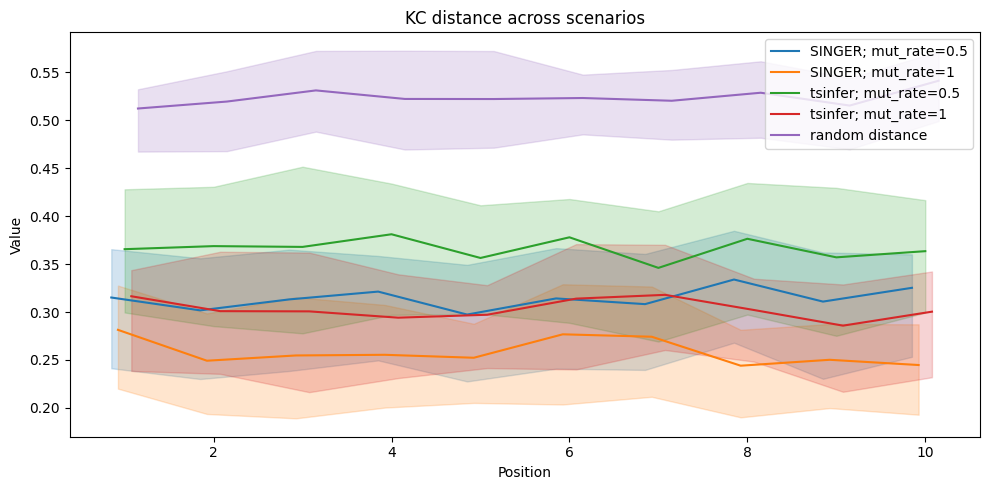

In [46]:
names = [
    "Ne2e+04_r5e-09_100_1e+06",
    "Ne2e+04_r1e-08_100_1e+06",
    "Ne2e+04_r2e-08_100_1e+06",
    "Ne2e+04_r5e-08_100_1e+06"
]

groups = []
for name in names[0:2]:
    dis = get_true_infer_dis(head, name, pos=pos, func=kc_dist_ts,lam=1)
    # print(name, "→", len(dis), "replicates found")
    groups.append(dis)
for name in names[0:2]:
    dis = get_true_tsinfer_dis(head, name, pos=pos, func=kc_dist_ts,lam=1)
    # print(name, "→", len(dis), "replicates found")
    groups.append(dis)

groups.append(get_random_dis(head, names[0], pos=pos, func=kc_dist_ts,lam=1))
plot_group_quantiles(groups,labels=["SINGER; mut_rate=0.5","SINGER; mut_rate=1","tsinfer; mut_rate=0.5","tsinfer; mut_rate=1","random distance"],  title="KC distance across scenarios")


/var/folders/kz/82_zg7j94hs8p268qx2hvkg80000gn/T/ipykernel_28300/603281777.py:98: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(flat_groups, patch_artist=True, labels=labels)


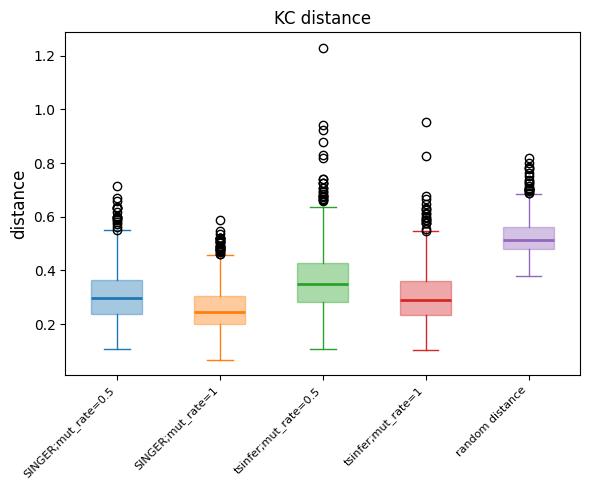

In [60]:
names = [
    "Ne2e+04_r5e-09_100_1e+06",
    "Ne2e+04_r1e-08_100_1e+06",
    "Ne2e+04_r2e-08_100_1e+06",
    "Ne2e+04_r5e-08_100_1e+06"
]

groups = []
for name in names[0:2]:
    dis = get_true_infer_dis(head, name, pos=pos, func=kc_dist_ts,lam=1)
    # print(name, "→", len(dis), "replicates found")
    groups.append(dis)
for name in names[0:2]:
    dis = get_true_tsinfer_dis(head, name, pos=pos, func=kc_dist_ts,lam=1)
    # print(name, "→", len(dis), "replicates found")
    groups.append(dis)

groups.append(get_random_dis(head, names[0], pos=pos, func=kc_dist_ts,lam=1))
plot_group_box(groups,labels=["SINGER;mut_rate=0.5","SINGER;mut_rate=1","tsinfer;mut_rate=0.5","tsinfer;mut_rate=1","random distance"],  title="KC distance")


In [29]:
true1,singer1=read_arg(head,names[0],0,"true"),read_arg(head,names[0],0,"singer")
true2,singer2=read_arg(head,names[1],0,"true"),read_arg(head,names[1],0,"singer")
true5,singer5=read_arg(head,names[2],0,"true"),read_arg(head,names[2],0,"singer")
true05,singer05=read_arg(head,names[3],0,"true"),read_arg(head,names[3],0,"singer")

In [30]:
pos=[i for i in range(int(1e4),int(1e6),int(1e4))]

In [33]:
dis1=kc_dist_ts(true1,singer1,pos,pos)
dis2=kc_dist_ts(true2,singer2,pos,pos)
dis3=kc_dist_ts(true5,singer5,pos,pos)
dis4=kc_dist_ts(true05,singer05,pos,pos)

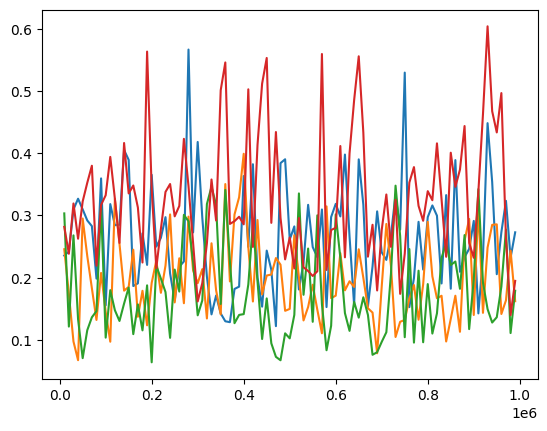

In [34]:
plt.plot(pos,dis1)
plt.plot(pos,dis2)
plt.plot(pos,dis3)
plt.plot(pos,dis4)